# Analisis de correos de phishing mediante aprendizaje supervisado

Este cuaderno fue depurado y reorganizado para conservar unicamente los bloques necesarios del flujo analitico final.  
La estructura sigue una secuencia tecnica coherente:

1. extraccion y consolidacion de datos desde MySQL,  
2. construccion del dataset analitico,  
3. definicion y ajuste de patrones de ingenieria social,  
4. validacion del modelo multietiqueta de patrones,  
5. construccion del riesgo derivado y su modelado,  
6. modelado del reporte de correos,  
7. generacion de graficas comparativas finales.

Se eliminaron bloques redundantes de exploracion intermedia, reentrenamientos descartados y versiones previas de reglas que ya fueron superadas por la configuracion final.


## 1. Importacion de librerias y configuracion de conexion

Este bloque centraliza las dependencias necesarias para el acceso a MySQL, el procesamiento tabular, la ingenieria de caracteristicas, la modelacion supervisada y la visualizacion de resultados.  
Tambien define la conexion al servidor para que el resto del cuaderno trabaje sobre un unico `engine` reutilizable.


In [1]:
import sys
import os
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import GroupShuffleSplit, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Configuracion de conexion
sys.path.append(os.path.abspath('..'))

from helpers.mysql_connections import create_mysql_engine


engine = create_mysql_engine()

## 2. Extraccion de datos y construccion del dataset maestro

Este bloque obtiene la informacion operativa principal desde la base de datos de GoPhish y la tabla de clasificacion textual.  
La estrategia evita una union SQL masiva por coincidencias de texto y traslada esa operacion a Python para mejorar control y trazabilidad.

El resultado de esta fase es `df_final`, un dataset enriquecido que relaciona:
- eventos de resultados,
- campañas,
- plantillas,
- solicitudes,
- registros de envio,
- y coincidencias con el vocabulario clasificado.


In [3]:
q_master = """
SELECT
    r.id AS result_id,
    r.campaign_id,
    r.user_id,
    r.r_id,
    r.email,
    r.first_name,
    r.last_name,
    r.position,
    r.status AS result_status,
    r.ip,
    r.latitude,
    r.longitude,
    r.send_date AS result_send_date,
    r.reported,
    r.modified_date,

    c.name AS campaign_name,
    c.status AS campaign_status,
    c.created_date AS campaign_created_date,
    c.completed_date AS campaign_completed_date,
    c.template_id,
    c.page_id,
    c.smtp_id,
    c.url AS campaign_url,
    c.launch_date,

    t.name AS template_name,
    t.subject AS template_subject,
    t.text AS template_text,
    t.modified_date AS template_modified_date,

    e.from_address,
    e.url AS request_url,
    e.template_id AS er_template_id,
    e.page_id AS er_page_id,

    m.send_date AS mail_send_date,
    m.send_attempt,
    m.processing

FROM gophish.results r
LEFT JOIN gophish.campaigns c
    ON r.campaign_id = c.id
LEFT JOIN gophish.templates t
    ON c.template_id = t.id
LEFT JOIN gophish.email_requests e
    ON r.r_id = e.r_id
LEFT JOIN gophish.mail_logs m
    ON r.r_id = m.r_id
"""

q_tc = """
SELECT
    id,
    text,
    context,
    subcontext,
    risk,
    message_type,
    text_level,
    intention,
    action_required,
    is_urgent,
    has_url,
    has_credentials
FROM gophish.text_clasification
"""

df_master = pd.read_sql(q_master, engine)
df_tc = pd.read_sql(q_tc, engine)

df_master["template_text"] = df_master["template_text"].fillna("").str.lower()
df_tc["text"] = df_tc["text"].fillna("").str.lower()

matches = []

for _, tc_row in df_tc.iterrows():
    term = tc_row["text"].strip()
    if not term:
        continue

    mask = df_master["template_text"].str.contains(term, regex=False, na=False)
    matched_rows = df_master.loc[mask, ["result_id", "template_id"]].copy()

    if not matched_rows.empty:
        matched_rows["classification_id"] = tc_row["id"]
        matched_rows["classification_text"] = tc_row["text"]
        matched_rows["context"] = tc_row["context"]
        matched_rows["subcontext"] = tc_row["subcontext"]
        matched_rows["risk"] = tc_row["risk"]
        matched_rows["message_type"] = tc_row["message_type"]
        matched_rows["text_level"] = tc_row["text_level"]
        matched_rows["intention"] = tc_row["intention"]
        matched_rows["action_required"] = tc_row["action_required"]
        matched_rows["is_urgent"] = tc_row["is_urgent"]
        matched_rows["has_url"] = tc_row["has_url"]
        matched_rows["has_credentials"] = tc_row["has_credentials"]
        matches.append(matched_rows)

df_matches = pd.concat(matches, ignore_index=True) if matches else pd.DataFrame()

df_final = df_master.merge(
    df_matches,
    on=["result_id", "template_id"],
    how="left"
)

print("Shape df_master:", df_master.shape)
print("Shape df_tc:", df_tc.shape)
print("Shape df_final:", df_final.shape)

Shape df_master: (10811, 35)
Shape df_tc: (27241, 12)
Shape df_final: (234155, 47)


## 3. Agregacion a nivel de observacion analitica

El dataset anterior contiene coincidencias múltiples por frase.  
Para modelado supervisado se requiere una estructura mas estable, por lo que este bloque consolida la informacion a nivel de `result_id`, resumiento contexto, riesgo, intencion y banderas binarias.

El resultado es `df_ml`, que funciona como base principal para la ingenieria de variables y los modelos posteriores.


In [4]:
def first_mode(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    if s.empty:
        return ""
    mode_vals = s.mode()
    if len(mode_vals) == 0:
        return s.iloc[0]
    return mode_vals.iloc[0]

df_work = df_final.copy()

for col in [
    "template_text", "template_subject", "context", "subcontext", "risk",
    "message_type", "text_level", "intention", "action_required",
    "position", "result_status"
]:
    if col in df_work.columns:
        df_work[col] = df_work[col].fillna("").astype(str).str.strip()

for col in ["is_urgent", "has_url", "has_credentials", "reported"]:
    if col in df_work.columns:
        df_work[col] = pd.to_numeric(df_work[col], errors="coerce").fillna(0).astype(int)

group_cols_base = [
    "result_id", "campaign_id", "user_id", "r_id", "email", "first_name", "last_name",
    "position", "result_status", "ip", "latitude", "longitude", "result_send_date",
    "reported", "modified_date", "campaign_name", "campaign_status",
    "campaign_created_date", "campaign_completed_date", "template_id", "page_id",
    "smtp_id", "campaign_url", "launch_date", "template_name", "template_subject",
    "template_text", "template_modified_date", "from_address", "request_url",
    "er_template_id", "er_page_id", "mail_send_date", "send_attempt", "processing"
]
group_cols_base = [c for c in group_cols_base if c in df_work.columns]

agg_dict = {
    "context": first_mode,
    "subcontext": first_mode,
    "risk": first_mode,
    "message_type": first_mode,
    "text_level": first_mode,
    "intention": first_mode,
    "action_required": first_mode,
    "is_urgent": "max",
    "has_url": "max",
    "has_credentials": "max",
    "classification_text": lambda x: " | ".join(sorted(set([str(v).strip() for v in x.dropna() if str(v).strip() != ""]))),
    "classification_id": "count"
}
agg_dict = {k: v for k, v in agg_dict.items() if k in df_work.columns}

df_ml = (
    df_work
    .groupby(group_cols_base, dropna=False, as_index=False)
    .agg(agg_dict)
    .rename(columns={
        "context": "context_detected",
        "subcontext": "subcontext_detected",
        "risk": "risk_detected",
        "message_type": "message_type_detected",
        "text_level": "text_level_detected",
        "intention": "intention_detected",
        "action_required": "action_required_detected",
        "is_urgent": "urgent_flag",
        "has_url": "url_flag",
        "has_credentials": "credentials_flag",
        "classification_text": "matched_terms",
        "classification_id": "match_count"
    })
)

print("Shape df_ml:", df_ml.shape)
df_ml.head()

Shape df_ml: (10811, 47)


,result_id,campaign_id,user_id,r_id,email,first_name,last_name,position,result_status,ip,...,risk_detected,message_type_detected,text_level_detected,intention_detected,action_required_detected,urgent_flag,url_flag,credentials_flag,matched_terms,match_count
0,1,1,1001,RID000101001000001mNnNDB,claudia.rivas1001@ventas-demo.com,Claudia,Rivas,Recepcionista,Submitted Data,81.127.12.122,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24
1,2,1,1002,RID000101002000002QkWQuI,ricardo.gomez1002@industrial-demo.com,Ricardo,Gomez,Supervisor de Mantenimiento,Submitted Data,174.63.183.97,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24
2,3,1,1003,RID000101003000003UgC1uv,marta.ramirez1003@servicios-demo.com,Marta,Ramirez,Tecnico de Soporte,Submitted Data,63.115.181.135,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24
3,4,1,1004,RID00010100400000442JXaf,luis.navarro1004@logistica-demo.com,Luis,Navarro,Asistente de Finanzas,Submitted Data,157.130.237.216,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24
4,5,1,1005,RID000101005000005dVnub8,ana.castro1005@corp-demo.com,Ana,Castro,Analista de RRHH,Clicked Link,135.2.101.56,...,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0,0,1,credenciales | sistema | usuario | verificacio...,24


## 4. Normalizacion textual y definicion final de patrones de ingenieria social

Este bloque implementa la version final de las reglas de etiquetado.  
Se eliminaron reglas intermedias que producian etiquetas casi constantes y se conservaron solo las expresiones que ofrecieron una distribucion mas util para entrenamiento.

Los patrones considerados son:
- urgencia,
- autoridad,
- solicitud de credenciales,
- amenaza,
- validacion,
- incentivo,
- curiosidad,
- contexto corporativo.

Estas etiquetas se utilizan despues tanto para caracterizacion como para prediccion de riesgo y de reporte.


In [5]:
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower().strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join([c for c in text if not unicodedata.combining(c)])
    text = re.sub(r"\s+", " ", text)
    return text

def count_matches(text, patterns):
    return sum(1 for p in patterns if re.search(p, text))

df_ml["subject_norm"] = df_ml["template_subject"].fillna("").apply(normalize_text)
df_ml["body_norm"] = df_ml["template_text"].fillna("").apply(normalize_text)
df_ml["text_full_norm"] = (df_ml["subject_norm"] + " " + df_ml["body_norm"]).str.strip()

txt = df_ml["text_full_norm"].fillna("")

urgency_soft = [
    r"\burgente\b", r"\baccion requerida\b", r"\baccion obligatoria\b",
    r"\binmediata\b", r"\binmediato\b", r"\bprioridad alta\b"
]
urgency_hard = [
    r"\bultim[oa] aviso\b", r"\bantes de\b", r"\ben las proximas? 24 horas\b",
    r"\bexpira hoy\b", r"\bvenc[eé] hoy\b", r"\bplazo final\b"
]
authority_patterns = [
    r"\bdepartamento de ti\b", r"\bequipo de seguridad\b", r"\bseguridad institucional\b",
    r"\bsoporte tecnico\b", r"\bmesa de ayuda\b", r"\badministrador del sistema\b",
    r"\bservicio de correo\b", r"\brecursos humanos\b", r"\brrhh\b",
    r"\bdepartamento financiero\b", r"\barea financiera\b", r"\binstitucional\b", r"\bcorporativo\b"
]
credentials_strong = [
    r"\binicie sesion\b", r"\biniciar sesion\b", r"\bcredencial digital\b",
    r"\bcredenciales\b", r"\bactualice sus credenciales\b", r"\brestablezca su clave\b",
    r"\busuario y contrasena\b", r"\bcontrasena\b", r"\bclave de acceso\b"
]
credentials_soft_a = [r"\bacceso\b", r"\bcuenta\b", r"\bperfil\b", r"\bcredencial\b"]
credentials_soft_b = [r"\bverificacion\b", r"\bvalidacion\b", r"\brestablecimiento\b", r"\brenovacion\b", r"\bactualizacion\b"]
credentials_exclusions = [r"\bconvocatoria\b", r"\bbeneficio\b"]

threat_patterns = [
    r"\bbloquead[oa]\b", r"\bsuspendid[oa]\b", r"\brestringid[oa]\b",
    r"\bacceso denegado\b", r"\bperdera acceso\b", r"\bentrega retenida\b",
    r"\bpago retenido\b", r"\bexcedio el limite\b", r"\binconsistencia documental\b",
    r"\bdesactivad[oa]\b", r"\bincumplimiento\b"
]
validation_strong = [
    r"\bverificacion de acceso\b", r"\bvalidacion de cuenta\b",
    r"\bconfirmacion de datos\b", r"\bconfirmacion obligatoria de datos\b",
    r"\bactualizacion de datos\b", r"\bconfirmar datos laborales\b",
    r"\bverifique su cuenta\b", r"\bverifique su informacion\b"
]
validation_soft = [
    r"\bverificacion\b", r"\bverificar\b", r"\bverifique\b", r"\bvalidacion\b",
    r"\bvalidar\b", r"\bconfirme\b", r"\bconfirmacion\b",
    r"\bactualizacion\b", r"\bactualice\b", r"\bactualizar\b"
]
validation_exclusions = [
    r"\bconvocatoria\b", r"\bbeneficio\b", r"\bfactura pendiente\b",
    r"\bpago retenido\b", r"\bdocumento compartido\b"
]
incentive_patterns = [r"\bbeneficio\b", r"\bbono\b", r"\bpremio\b", r"\brecompensa\b", r"\bdescuento\b", r"\breembolso\b", r"\bincentivo\b", r"\boferta\b"]
curiosity_patterns = [r"\bactividad inusual\b", r"\bdocumento compartido\b", r"\bfactura pendiente\b", r"\bpago retenido\b", r"\barchivo adjunto\b", r"\bconsulte el documento\b", r"\bvea el archivo\b", r"\bnotificacion interna\b", r"\bse detecto actividad\b", r"\bmensaje pendiente\b"]
corporate_strong = [r"\bvpn\b", r"\bcorreo corporativo\b", r"\bportal interno\b", r"\bintranet\b", r"\bcredencial digital\b"]
corporate_soft = [r"\bbuzon\b", r"\bdatos laborales\b", r"\brecursos humanos\b", r"\brrhh\b", r"\barea financiera\b", r"\bdepartamento financiero\b", r"\balmacenamiento\b", r"\bperfil\b", r"\bcorporativo\b", r"\binstitucional\b"]

def rule_urgency(text):
    return int((count_matches(text, urgency_soft) >= 2) or (count_matches(text, urgency_hard) >= 1))

def rule_authority(text):
    return int(count_matches(text, authority_patterns) >= 1)

def rule_credentials(text):
    if any(re.search(p, text) for p in credentials_exclusions):
        return 0
    return int((count_matches(text, credentials_strong) >= 1) or ((count_matches(text, credentials_soft_a) >= 1) and (count_matches(text, credentials_soft_b) >= 1)))

def rule_threat(text):
    return int(count_matches(text, threat_patterns) >= 1)

def rule_validation(text):
    if any(re.search(p, text) for p in validation_exclusions):
        return 0
    return int((count_matches(text, validation_strong) >= 1) or (count_matches(text, validation_soft) >= 2))

def rule_incentive(text):
    return int(count_matches(text, incentive_patterns) >= 1)

def rule_curiosity(text):
    return int(count_matches(text, curiosity_patterns) >= 1)

def rule_corporate(text):
    return int((count_matches(text, corporate_strong) >= 1) or (count_matches(text, corporate_soft) >= 2))

df_ml["pattern_urgency"] = txt.apply(rule_urgency)
df_ml["pattern_authority"] = txt.apply(rule_authority)
df_ml["pattern_credentials"] = txt.apply(rule_credentials)
df_ml["pattern_threat"] = txt.apply(rule_threat)
df_ml["pattern_validation"] = txt.apply(rule_validation)
df_ml["pattern_incentive"] = txt.apply(rule_incentive)
df_ml["pattern_curiosity"] = txt.apply(rule_curiosity)
df_ml["pattern_corporate_context"] = txt.apply(rule_corporate)

pattern_cols = [
    "pattern_urgency", "pattern_authority", "pattern_credentials", "pattern_threat",
    "pattern_validation", "pattern_incentive", "pattern_curiosity", "pattern_corporate_context"
]

df_templates_final = (
    df_ml[
        ["template_id", "template_subject", "template_text", "text_full_norm"] + pattern_cols
    ]
    .drop_duplicates(subset=["template_id"])
    .sort_values("template_id")
    .reset_index(drop=True)
)

summary_final = pd.DataFrame({
    "positives": df_templates_final[pattern_cols].sum(),
    "negatives": len(df_templates_final) - df_templates_final[pattern_cols].sum(),
    "positive_rate": df_templates_final[pattern_cols].mean()
}).sort_values("positive_rate", ascending=False)

print("Shape df_templates_final:", df_templates_final.shape)
print(summary_final)

Shape df_templates_final: (13, 12)
                           positives  negatives  positive_rate
pattern_credentials               11          2       0.846154
pattern_validation                 8          5       0.615385
pattern_corporate_context          6          7       0.461538
pattern_urgency                    5          8       0.384615
pattern_curiosity                  4          9       0.307692
pattern_threat                     3         10       0.230769
pattern_authority                  2         11       0.153846
pattern_incentive                  1         12       0.076923


## 5. Validacion del detector de patrones a nivel de plantilla unica

La evaluacion de patrones se realiza exclusivamente con `templates` unicos y validacion Leave-One-Out.  
Esta decision evita fuga de informacion entre ejemplos duplicados y permite una evaluacion mas honesta del clasificador multietiqueta.

El modelo combina:
- TF-IDF sobre asunto y cuerpo,
- regresion logistica,
- estrategia One-vs-Rest para multiples etiquetas simultaneas.


In [6]:
df_eval = df_templates_final.copy()
df_eval["text_full"] = (
    df_eval["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_eval["template_text"].fillna("").astype(str).str.strip()
).str.strip()

X = df_eval["text_full"].reset_index(drop=True)
Y = df_eval[pattern_cols].fillna(0).astype(int).reset_index(drop=True)

loo = LeaveOneOut()
all_true = []
all_pred = []
rows_compare = []

for fold, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

    trainable_cols = []
    skipped_cols = []

    for col in pattern_cols:
        if y_train[col].nunique() >= 2:
            trainable_cols.append(col)
        else:
            skipped_cols.append(col)

    y_pred_fold = pd.DataFrame(index=y_test.index)

    if trainable_cols:
        model_patterns_final = Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
            ("clf", OneVsRestClassifier(
                LogisticRegression(max_iter=2000, class_weight="balanced")
            ))
        ])

        model_patterns_final.fit(X_train, y_train[trainable_cols])
        pred_partial = model_patterns_final.predict(X_test)

        pred_partial_df = pd.DataFrame(
            pred_partial,
            columns=trainable_cols,
            index=y_test.index
        )
        y_pred_fold = pd.concat([y_pred_fold, pred_partial_df], axis=1)

    for col in skipped_cols:
        y_pred_fold[col] = y_train[col].iloc[0]

    y_pred_fold = y_pred_fold[pattern_cols]

    all_true.append(y_test.values[0])
    all_pred.append(y_pred_fold.values[0])

    row_result = {
        "fold": fold,
        "template_id": df_eval.iloc[test_idx[0]]["template_id"],
        "template_subject": df_eval.iloc[test_idx[0]]["template_subject"]
    }
    for col in pattern_cols:
        row_result[f"real_{col}"] = int(y_test.iloc[0][col])
        row_result[f"pred_{col}"] = int(y_pred_fold.iloc[0][col])
    rows_compare.append(row_result)

y_true_patterns = np.array(all_true)
y_pred_patterns = np.array(all_pred)

for i, col in enumerate(pattern_cols):
    print("\n" + "=" * 80)
    print(f"REPORTE DE CLASIFICACION - {col}")
    print("=" * 80)
    print(classification_report(y_true_patterns[:, i], y_pred_patterns[:, i], zero_division=0))

df_compare_templates = pd.DataFrame(rows_compare)
df_compare_templates.head()


REPORTE DE CLASIFICACION - pattern_urgency
              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.67      0.80      0.73         5

    accuracy                           0.77        13
   macro avg       0.76      0.78      0.76        13
weighted avg       0.78      0.77      0.77        13


REPORTE DE CLASIFICACION - pattern_authority
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        11
           1       0.00      0.00      0.00         2

    accuracy                           0.85        13
   macro avg       0.42      0.50      0.46        13
weighted avg       0.72      0.85      0.78        13


REPORTE DE CLASIFICACION - pattern_credentials
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.85      1.00      0.92        11

    accuracy                           0.85 

,fold,template_id,template_subject,real_pattern_urgency,pred_pattern_urgency,real_pattern_authority,pred_pattern_authority,real_pattern_credentials,pred_pattern_credentials,real_pattern_threat,pred_pattern_threat,real_pattern_validation,pred_pattern_validation,real_pattern_incentive,pred_pattern_incentive,real_pattern_curiosity,pred_pattern_curiosity,real_pattern_corporate_context,pred_pattern_corporate_context
0,1,1,Verificacion urgente de acceso institucional,0,0,1,0,1,1,0,0,1,1,0,0,0,0,1,1
1,2,2,Entrega retenida - accion requerida,1,0,0,0,1,1,1,0,1,1,0,0,0,0,0,1
2,3,3,Actividad inusual detectada en su perfil,0,0,0,0,1,1,0,0,1,1,0,0,1,0,0,1
3,4,4,Accion requerida: actualizacion de VPN corpora...,0,1,0,0,1,1,0,0,1,1,0,0,0,0,1,1
4,5,5,Documento compartido requiere revision inmediata,1,1,0,0,1,1,0,0,0,1,0,0,1,0,0,0


## 6. Construccion del riesgo derivado por reglas

La variable de riesgo original no presento variabilidad suficiente para modelado multiclase.  
Por ello se construye un riesgo derivado a partir de una puntuacion ponderada que integra:
- amenaza,
- credenciales,
- urgencia,
- validacion,
- autoridad,
- contexto corporativo,
- banderas tecnicas.

La transformacion final asigna tres niveles:
- Bajo,
- Medio,
- Alto.


In [7]:
risk_cols_base = [
    "template_id", "template_subject", "template_text", "text_full_norm", "risk_detected",
    "urgent_flag", "url_flag", "credentials_flag",
    "context_detected", "subcontext_detected", "message_type_detected",
    "text_level_detected", "intention_detected", "action_required_detected"
] + pattern_cols

risk_cols_base = [c for c in risk_cols_base if c in df_ml.columns]

df_risk = (
    df_ml[risk_cols_base]
    .drop_duplicates(subset=["template_id"])
    .copy()
)

df_risk["text_full"] = (
    df_risk["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_risk["template_text"].fillna("").astype(str).str.strip()
).str.strip()

df_risk_rules = df_risk.copy()

rule_num_cols = [
    "urgent_flag", "url_flag", "credentials_flag",
    "pattern_urgency", "pattern_authority", "pattern_credentials",
    "pattern_threat", "pattern_validation", "pattern_incentive",
    "pattern_curiosity", "pattern_corporate_context"
]

for c in rule_num_cols:
    if c in df_risk_rules.columns:
        df_risk_rules[c] = pd.to_numeric(df_risk_rules[c], errors="coerce").fillna(0)

df_risk_rules["risk_score"] = (
    2.0 * df_risk_rules.get("pattern_threat", 0) +
    2.0 * df_risk_rules.get("pattern_credentials", 0) +
    1.5 * df_risk_rules.get("pattern_urgency", 0) +
    1.5 * df_risk_rules.get("pattern_validation", 0) +
    1.0 * df_risk_rules.get("pattern_authority", 0) +
    1.0 * df_risk_rules.get("pattern_corporate_context", 0) +
    1.0 * df_risk_rules.get("credentials_flag", 0) +
    0.5 * df_risk_rules.get("url_flag", 0) +
    0.5 * df_risk_rules.get("pattern_curiosity", 0) +
    0.5 * df_risk_rules.get("pattern_incentive", 0)
)

def map_risk(score):
    if score <= 2.0:
        return 0
    elif score <= 5.0:
        return 1
    return 2

risk_label_map = {0: "Bajo", 1: "Medio", 2: "Alto"}

df_risk_rules["risk_target_rule"] = df_risk_rules["risk_score"].apply(map_risk)
df_risk_rules["risk_label_rule"] = df_risk_rules["risk_target_rule"].map(risk_label_map)

print(df_risk_rules[["template_id", "risk_score", "risk_target_rule", "risk_label_rule"]].sort_values(["risk_target_rule", "risk_score"]))

       template_id  risk_score  risk_target_rule risk_label_rule
10810           16         0.0                 0            Bajo
423             10         1.5                 0            Bajo
94               3         5.0                 1           Medio
188              5         5.0                 1           Medio
282              7         5.0                 1           Medio
141              4         5.5                 2            Alto
329              8         5.5                 2            Alto
517             12         5.5                 2            Alto
0                1         6.5                 2            Alto
235              6         6.5                 2            Alto
470             11         7.0                 2            Alto
47               2         8.0                 2            Alto
376              9         9.0                 2            Alto


## 7. Modelo de riesgo con validacion Leave-One-Out

Este modelo estima el riesgo derivado utilizando una arquitectura híbrida:
- texto vectorizado con TF-IDF,
- banderas numericas,
- variables categoricas codificadas,
- regresion logistica multiclase.

La evaluacion Leave-One-Out es apropiada por el bajo numero de plantillas unicas y permite observar la capacidad de generalizacion del modelo ante plantillas no vistas.


In [8]:
text_col = "text_full"

num_cols_risk = [
    "urgent_flag", "url_flag", "credentials_flag",
    "pattern_urgency", "pattern_authority", "pattern_credentials",
    "pattern_threat", "pattern_validation", "pattern_incentive",
    "pattern_curiosity", "pattern_corporate_context"
]
num_cols_risk = [c for c in num_cols_risk if c in df_risk_rules.columns]

cat_cols_risk = [
    "context_detected", "subcontext_detected", "message_type_detected",
    "text_level_detected", "intention_detected", "action_required_detected"
]
cat_cols_risk = [c for c in cat_cols_risk if c in df_risk_rules.columns]

for c in cat_cols_risk:
    df_risk_rules[c] = df_risk_rules[c].fillna("").astype(str).str.strip()

for c in num_cols_risk:
    df_risk_rules[c] = pd.to_numeric(df_risk_rules[c], errors="coerce").fillna(0)

X_risk = df_risk_rules[[text_col] + num_cols_risk + cat_cols_risk].copy()
y_risk = df_risk_rules["risk_target_rule"].copy()

preprocessor_risk = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=1), text_col),
    ("num", "passthrough", num_cols_risk),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_risk)
])

loo = LeaveOneOut()
risk_true = []
risk_pred = []
rows_compare_risk = []

for fold, (train_idx, test_idx) in enumerate(loo.split(X_risk), start=1):
    X_train = X_risk.iloc[train_idx]
    X_test = X_risk.iloc[test_idx]
    y_train = y_risk.iloc[train_idx]
    y_test = y_risk.iloc[test_idx]

    if y_train.nunique() < 2:
        y_pred_fold = np.array([int(y_train.mode().iloc[0])])
    else:
        model_risk_rule = Pipeline([
            ("prep", preprocessor_risk),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ])
        model_risk_rule.fit(X_train, y_train)
        y_pred_fold = model_risk_rule.predict(X_test)

    risk_true.append(int(y_test.iloc[0]))
    risk_pred.append(int(y_pred_fold[0]))

    rows_compare_risk.append({
        "fold": fold,
        "template_id": int(df_risk_rules.iloc[test_idx[0]]["template_id"]),
        "template_subject": df_risk_rules.iloc[test_idx[0]]["template_subject"],
        "real_risk": int(y_test.iloc[0]),
        "pred_risk": int(y_pred_fold[0])
    })

y_true_risk = np.array(risk_true)
y_pred_risk = np.array(risk_pred)

print(classification_report(y_true_risk, y_pred_risk, zero_division=0))
print("Accuracy :", round(accuracy_score(y_true_risk, y_pred_risk), 4))
print("Macro F1 :", round(f1_score(y_true_risk, y_pred_risk, average="macro", zero_division=0), 4))
print("Weighted F1 :", round(f1_score(y_true_risk, y_pred_risk, average="weighted", zero_division=0), 4))

cm_risk = confusion_matrix(y_true_risk, y_pred_risk, labels=[0, 1, 2])
df_cm_risk = pd.DataFrame(
    cm_risk,
    index=["Real_Bajo", "Real_Medio", "Real_Alto"],
    columns=["Pred_Bajo", "Pred_Medio", "Pred_Alto"]
)
df_cm_risk

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      0.67      0.57         3
           2       0.88      0.88      0.88         8

    accuracy                           0.77        13
   macro avg       0.79      0.68      0.70        13
weighted avg       0.81      0.77      0.77        13

Accuracy : 0.7692
Macro F1 : 0.7044
Weighted F1 : 0.7729


,Pred_Bajo,Pred_Medio,Pred_Alto
Real_Bajo,1,1,0
Real_Medio,0,2,1
Real_Alto,0,1,7


## 8. Interpretabilidad del modelo de riesgo

Para obtener una lectura tecnica de las variables mas influyentes, se entrena el modelo final sobre todo el conjunto disponible y se inspeccionan los coeficientes de la regresion logistica.

Esta fase permite identificar:
- terminos textuales que empujan hacia un nivel de riesgo,
- patrones de ingenieria social con mayor peso,
- y variables estructuradas con mayor poder explicativo.


In [9]:
X_all = df_risk_rules[[text_col] + num_cols_risk + cat_cols_risk].copy()
y_all = df_risk_rules["risk_target_rule"].copy()

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
preprocessor_full_risk = ColumnTransformer([
    ("text", tfidf, text_col),
    ("num", "passthrough", num_cols_risk),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_risk)
])

model_risk_final = Pipeline([
    ("prep", preprocessor_full_risk),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_risk_final.fit(X_all, y_all)

feature_names_risk = model_risk_final.named_steps["prep"].get_feature_names_out()
coef_matrix_risk = model_risk_final.named_steps["clf"].coef_

class_map = {0: "Bajo", 1: "Medio", 2: "Alto"}

for class_idx, class_label in class_map.items():
    df_imp = pd.DataFrame({
        "feature": feature_names_risk,
        "coef": coef_matrix_risk[class_idx],
        "abs_coef": np.abs(coef_matrix_risk[class_idx])
    }).sort_values("coef", ascending=False)

    print("\n" + "=" * 90)
    print(f"TOP VARIABLES QUE EMPUJAN HACIA RIESGO {class_label.upper()}")
    print("=" * 90)
    print(df_imp.head(15)[["feature", "coef"]])


TOP VARIABLES QUE EMPUJAN HACIA RIESGO BAJO
                             feature      coef
1261          num__pattern_incentive  0.498350
194                  text__beneficio  0.165266
1264          cat__context_detected_  0.141573
1276        cat__intention_detected_  0.141573
1268       cat__subcontext_detected_  0.141573
1278  cat__action_required_detected_  0.141573
1274       cat__text_level_detected_  0.141573
1272     cat__message_type_detected_  0.141573
666                    text__interno  0.099159
1167              text__un beneficio  0.099159
196          text__beneficio interno  0.099159
667          text__interno pendiente  0.099159
353            text__de confirmacion  0.099159
840               text__pendiente de  0.070728
1151                  text__tiene un  0.066106

TOP VARIABLES QUE EMPUJAN HACIA RIESGO MEDIO
                                             feature      coef
1262                          num__pattern_curiosity  0.774465
1258                        num

## 9. Construccion del dataset de reporte a nivel de resultado

A diferencia del riesgo, el reporte es un comportamiento individual del usuario y no debe modelarse solamente a nivel de plantilla.  
Por ello el dataset de reporte se construye a nivel de `result_id`, incorporando:
- texto de la plantilla,
- banderas tecnicas,
- contexto,
- cargo del usuario,
- estado del correo,
- patrones de ingenieria social,
- y posteriormente el riesgo derivado.


In [10]:
report_cols_result = [
    "result_id", "template_id", "user_id", "email", "first_name", "last_name",
    "position", "result_status", "reported", "template_subject", "template_text",
    "urgent_flag", "url_flag", "credentials_flag",
    "context_detected", "subcontext_detected", "message_type_detected",
    "text_level_detected", "intention_detected", "action_required_detected"
] + pattern_cols

report_cols_result = [c for c in report_cols_result if c in df_ml.columns]

df_report_result = df_ml[report_cols_result].copy()
df_report_result["reported_target"] = pd.to_numeric(
    df_report_result["reported"], errors="coerce"
).fillna(0).astype(int)

df_report_result["text_full"] = (
    df_report_result["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_report_result["template_text"].fillna("").astype(str).str.strip()
).str.strip()

risk_merge_cols = ["template_id", "risk_score", "risk_target_rule", "risk_label_rule"]
df_report_result = df_report_result.merge(
    df_risk_rules[risk_merge_cols].drop_duplicates(subset=["template_id"]),
    on="template_id",
    how="left"
)

print("Shape df_report_result:", df_report_result.shape)
print(df_report_result["reported_target"].value_counts(dropna=False))
print(df_report_result["reported_target"].value_counts(normalize=True, dropna=False))

Shape df_report_result: (10811, 33)
reported_target
0    10619
1      192
Name: count, dtype: int64
reported_target
0    0.98224
1    0.01776
Name: proportion, dtype: float64


## 10. Modelo de reporte con regresion logistica

Este primer modelo intenta predecir el reporte a nivel de resultado combinando:
- texto del correo,
- variables numericas,
- variables categoricas,
- y agrupacion por `template_id` en la particion train/test.

El objetivo de esta fase es medir si existe señal suficiente para discriminar correos reportados frente a no reportados bajo un escenario altamente desbalanceado.


In [11]:
num_cols_report = [
    "urgent_flag", "url_flag", "credentials_flag", "risk_score", "risk_target_rule",
    "pattern_urgency", "pattern_authority", "pattern_credentials", "pattern_threat",
    "pattern_validation", "pattern_incentive", "pattern_curiosity", "pattern_corporate_context"
]
num_cols_report = [c for c in num_cols_report if c in df_report_result.columns]

cat_cols_report = [
    "position", "result_status", "context_detected", "subcontext_detected",
    "message_type_detected", "text_level_detected", "intention_detected",
    "action_required_detected", "risk_label_rule"
]
cat_cols_report = [c for c in cat_cols_report if c in df_report_result.columns]

for c in cat_cols_report:
    df_report_result[c] = df_report_result[c].fillna("").astype(str).str.strip()

for c in num_cols_report:
    df_report_result[c] = pd.to_numeric(df_report_result[c], errors="coerce").fillna(0)

X_report = df_report_result[["text_full"] + num_cols_report + cat_cols_report].copy()
y_report = df_report_result["reported_target"].copy()
groups_report = df_report_result["template_id"]

preprocessor_report = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=2), "text_full"),
    ("num", "passthrough", num_cols_report),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_report)
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_report, y_report, groups=groups_report))

X_train = X_report.iloc[train_idx]
X_test = X_report.iloc[test_idx]
y_train = y_report.iloc[train_idx]
y_test = y_report.iloc[test_idx]

model_report_result = Pipeline([
    ("prep", preprocessor_report),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_report_result.fit(X_train, y_train)
y_pred_report_lr = model_report_result.predict(X_test)

print(classification_report(y_test, y_pred_report_lr, zero_division=0))
print("Accuracy :", round(accuracy_score(y_test, y_pred_report_lr), 4))
print("Macro F1 :", round(f1_score(y_test, y_pred_report_lr, average="macro", zero_division=0), 4))
print("Weighted F1 :", round(f1_score(y_test, y_pred_report_lr, average="weighted", zero_division=0), 4))

cm_report_lr = confusion_matrix(y_test, y_pred_report_lr, labels=[0, 1])
df_cm_report_lr = pd.DataFrame(
    cm_report_lr,
    index=["Real_NoReportado", "Real_Reportado"],
    columns=["Pred_NoReportado", "Pred_Reportado"]
)
df_cm_report_lr

              precision    recall  f1-score   support

           0       0.98      0.62      0.76      2676
           1       0.02      0.36      0.03        50

    accuracy                           0.61      2726
   macro avg       0.50      0.49      0.39      2726
weighted avg       0.96      0.61      0.74      2726

Accuracy : 0.6104
Macro F1 : 0.3944
Weighted F1 : 0.7428


,Pred_NoReportado,Pred_Reportado
Real_NoReportado,1646,1030
Real_Reportado,32,18


## 11. Analisis de umbral de decision para la clase reportada

Dado el fuerte desbalance entre correos reportados y no reportados, se inspeccionan las probabilidades del modelo lineal con distintos umbrales.  
Esta fase permite observar el intercambio entre:
- precision,
- recall,
- F1 de la clase positiva,
- y volumen de positivos predichos.


In [12]:
y_prob_report = model_report_result.predict_proba(X_test)[:, 1]
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

rows_thresholds = []

for thr in thresholds:
    y_pred_thr = (y_prob_report >= thr).astype(int)
    rows_thresholds.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_test, y_pred_thr),
        "precision_reported": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall_reported": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1_reported": f1_score(y_test, y_pred_thr, zero_division=0),
        "predicted_positives": int(y_pred_thr.sum())
    })

df_thresholds = pd.DataFrame(rows_thresholds)
df_thresholds

,threshold,accuracy,precision_reported,recall_reported,f1_reported,predicted_positives
0,0.1,0.018342,0.018342,1.00,0.036023,2726
1,0.2,0.018342,0.018342,1.00,0.036023,2726
2,0.3,0.018342,0.018342,1.00,0.036023,2726
3,0.4,0.045488,0.018854,1.00,0.037010,2652
4,0.5,0.610418,0.017176,0.36,0.032787,1048
5,0.6,0.927733,0.019608,0.06,0.029557,153
6,0.7,0.981658,0.000000,0.00,0.000000,0


## 12. Modelo de reporte tabular con Random Forest

Este bloque representa la version final de la tarea de reporte.  
Se elimina el texto para reducir ruido de alta dimensionalidad y se emplea un modelo de bosques aleatorios sobre variables estructuradas:
- banderas tecnicas,
- patrones de ingenieria social,
- riesgo derivado,
- cargo,
- estado del correo,
- contexto e intencion.

El objetivo es evaluar si una estructura no lineal mejora la discriminacion de la clase positiva.


In [13]:
df_report_rf = df_report_result.copy()

X_rf = df_report_rf[num_cols_report + [c for c in cat_cols_report if c != "risk_label_rule"] + ["risk_label_rule"]].copy()
y_rf = df_report_rf["reported_target"].copy()
groups_rf = df_report_rf["template_id"]

preprocessor_rf = ColumnTransformer([
    ("num", "passthrough", num_cols_report),
    ("cat", OneHotEncoder(handle_unknown="ignore"), [c for c in X_rf.columns if c not in num_cols_report])
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_rf, test_idx_rf = next(gss.split(X_rf, y_rf, groups=groups_rf))

X_train_rf = X_rf.iloc[train_idx_rf]
X_test_rf = X_rf.iloc[test_idx_rf]
y_train_rf = y_rf.iloc[train_idx_rf]
y_test_rf = y_rf.iloc[test_idx_rf]

model_report_rf = Pipeline([
    ("prep", preprocessor_rf),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

model_report_rf.fit(X_train_rf, y_train_rf)
y_pred_report_rf = model_report_rf.predict(X_test_rf)

print(classification_report(y_test_rf, y_pred_report_rf, zero_division=0))
print("Accuracy :", round(accuracy_score(y_test_rf, y_pred_report_rf), 4))
print("Macro F1 :", round(f1_score(y_test_rf, y_pred_report_rf, average="macro", zero_division=0), 4))
print("Weighted F1 :", round(f1_score(y_test_rf, y_pred_report_rf, average="weighted", zero_division=0), 4))

cm_report_rf = confusion_matrix(y_test_rf, y_pred_report_rf, labels=[0, 1])
df_cm_report_rf = pd.DataFrame(
    cm_report_rf,
    index=["Real_NoReportado", "Real_Reportado"],
    columns=["Pred_NoReportado", "Pred_Reportado"]
)
df_cm_report_rf

              precision    recall  f1-score   support

           0       0.98      0.89      0.93      2676
           1       0.01      0.08      0.02        50

    accuracy                           0.87      2726
   macro avg       0.50      0.48      0.48      2726
weighted avg       0.96      0.87      0.92      2726

Accuracy : 0.8734
Macro F1 : 0.4775
Weighted F1 : 0.9157


,Pred_NoReportado,Pred_Reportado
Real_NoReportado,2377,299
Real_Reportado,46,4


# Graficas finales comparativas

Las siguientes figuras sintetizan el rendimiento de los modelos desarrollados y la distribucion de variables clave del estudio.  
Cada grafica se presenta en un bloque independiente para facilitar su lectura, exportacion y reutilizacion en la defensa del proyecto.


## Grafica 1. Comparacion de accuracy entre modelos

Esta visualizacion resume el desempeno general de tres componentes representativos del analisis:
- deteccion de patrones,
- clasificacion de riesgo,
- prediccion de reporte con Random Forest.


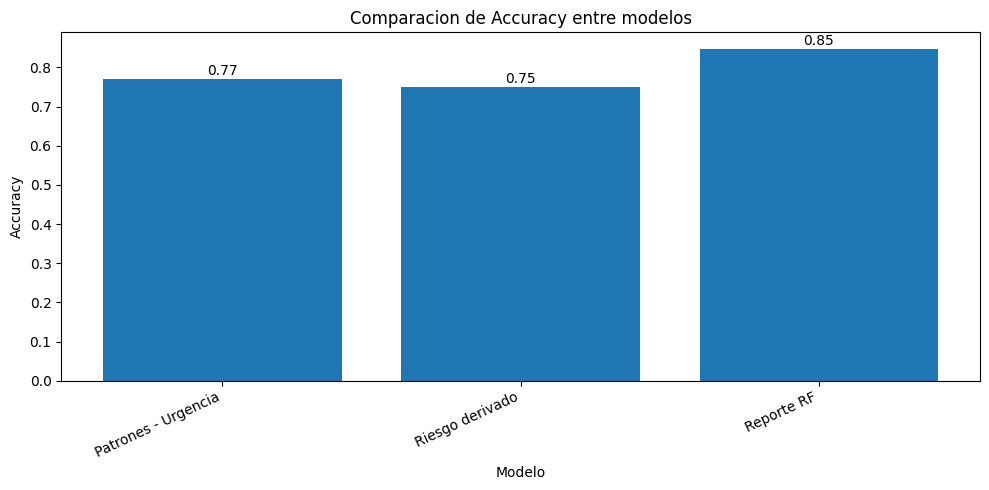

In [14]:
df_model_metrics = pd.DataFrame({
    "modelo": ["Patrones - Urgencia", "Riesgo derivado", "Reporte RF"],
    "accuracy": [0.77, 0.75, 0.8474],
    "macro_f1": [0.76, 0.4821, 0.4704],
    "weighted_f1": [0.77, 0.7262, 0.9008]
})

plt.figure(figsize=(10, 5))
plt.bar(df_model_metrics["modelo"], df_model_metrics["accuracy"])
plt.title("Comparacion de Accuracy entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(df_model_metrics["accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

## Grafica 2. Comparacion de Macro F1 entre modelos

El Macro F1 resulta especialmente util cuando existe desbalance entre clases, ya que evalua el desempeno promedio sin favorecer a la clase mayoritaria.


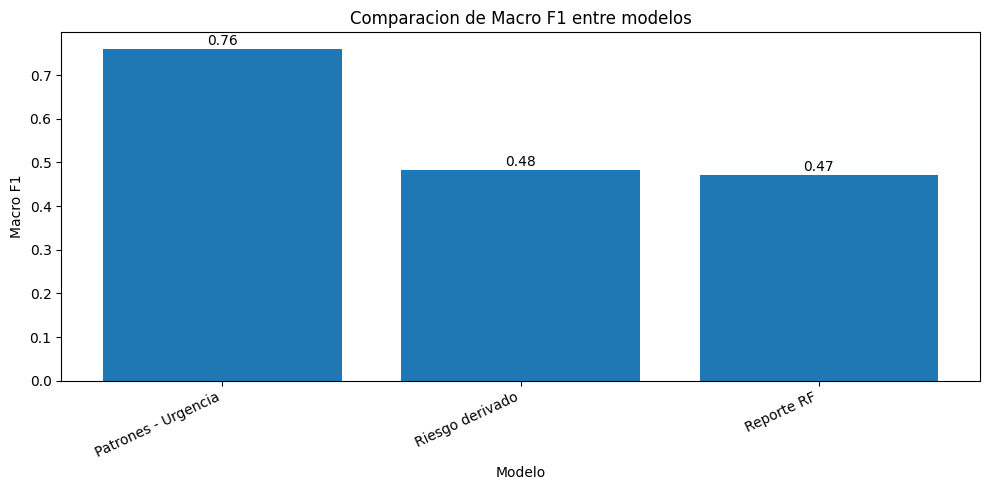

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(df_model_metrics["modelo"], df_model_metrics["macro_f1"])
plt.title("Comparacion de Macro F1 entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Macro F1")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(df_model_metrics["macro_f1"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

## Grafica 3. Comparacion de Weighted F1 entre modelos

El Weighted F1 pondera el rendimiento por frecuencia de clase y ayuda a contextualizar el efecto del desbalance sobre los clasificadores.


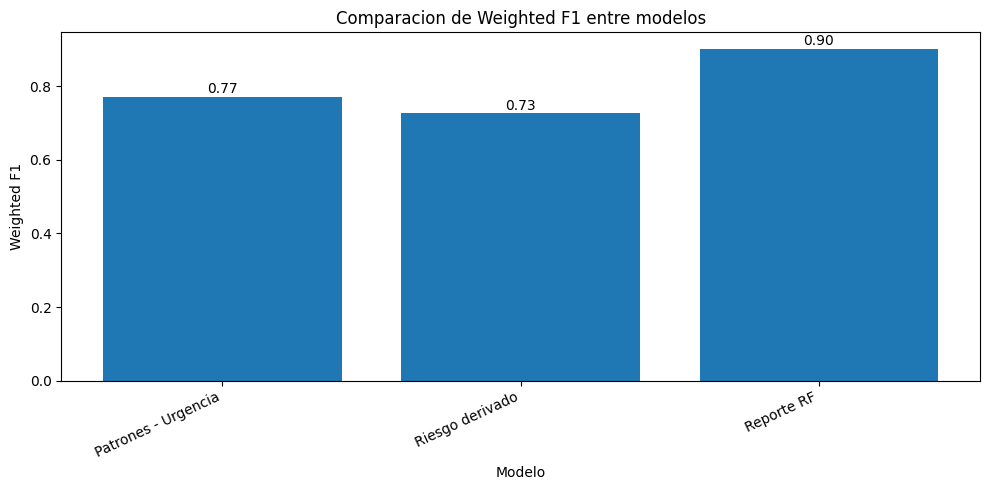

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(df_model_metrics["modelo"], df_model_metrics["weighted_f1"])
plt.title("Comparacion de Weighted F1 entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Weighted F1")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(df_model_metrics["weighted_f1"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

## Grafica 4. Distribucion final de patrones de ingenieria social

Esta figura resume cuantos templates activaron cada patron despues del proceso de depuracion semantica y balanceo de reglas.


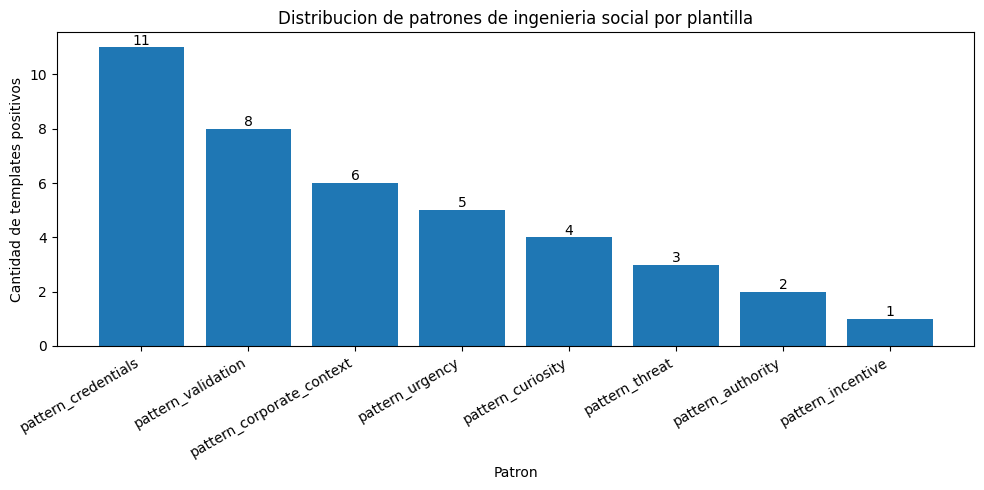

In [17]:
pattern_summary = pd.DataFrame({
    "pattern": pattern_cols,
    "positives": [df_templates_final[c].sum() for c in pattern_cols]
}).sort_values("positives", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(pattern_summary["pattern"], pattern_summary["positives"])
plt.title("Distribucion de patrones de ingenieria social por plantilla")
plt.xlabel("Patron")
plt.ylabel("Cantidad de templates positivos")
plt.xticks(rotation=30, ha="right")
for i, v in enumerate(pattern_summary["positives"]):
    plt.text(i, v + 0.1, f"{int(v)}", ha="center")
plt.tight_layout()
plt.show()

## Grafica 5. Matriz de confusion del modelo de riesgo derivado

La matriz muestra la capacidad del modelo para discriminar entre riesgo bajo, medio y alto a partir de texto, patrones y banderas tecnicas.


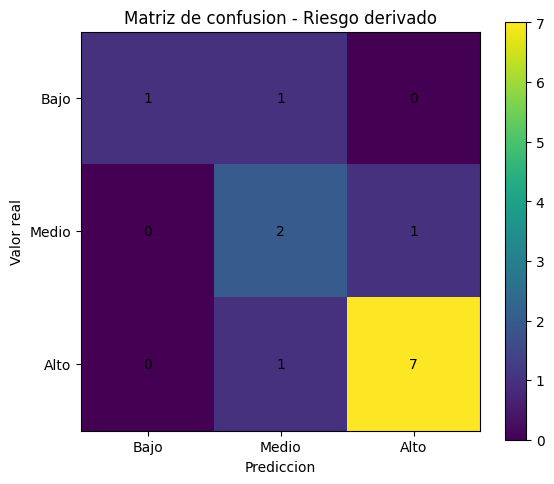

In [18]:
plt.figure(figsize=(6, 5))
plt.imshow(cm_risk, interpolation="nearest")
plt.title("Matriz de confusion - Riesgo derivado")
plt.colorbar()
plt.xticks(np.arange(3), ["Bajo", "Medio", "Alto"])
plt.yticks(np.arange(3), ["Bajo", "Medio", "Alto"])
plt.xlabel("Prediccion")
plt.ylabel("Valor real")

for i in range(cm_risk.shape[0]):
    for j in range(cm_risk.shape[1]):
        plt.text(j, i, str(cm_risk[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

## Grafica 6. Matriz de confusion del modelo de reporte con Random Forest

Esta matriz representa el comportamiento final del mejor modelo obtenido para la tarea de reporte de correos.


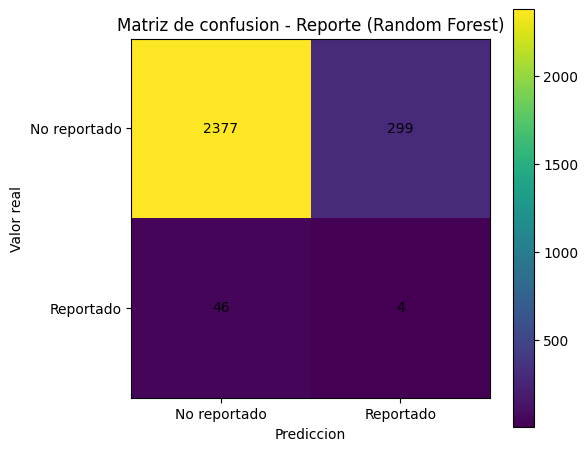

In [19]:
plt.figure(figsize=(6, 5))
plt.imshow(cm_report_rf, interpolation="nearest")
plt.title("Matriz de confusion - Reporte (Random Forest)")
plt.colorbar()
plt.xticks(np.arange(2), ["No reportado", "Reportado"])
plt.yticks(np.arange(2), ["No reportado", "Reportado"])
plt.xlabel("Prediccion")
plt.ylabel("Valor real")

for i in range(cm_report_rf.shape[0]):
    for j in range(cm_report_rf.shape[1]):
        plt.text(j, i, str(cm_report_rf[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

## Grafica 7. Analisis de thresholds en el modelo lineal de reporte

Esta curva compara el efecto de diferentes umbrales sobre accuracy, precision, recall y F1 de la clase reportada, permitiendo evaluar la calibracion del clasificador.


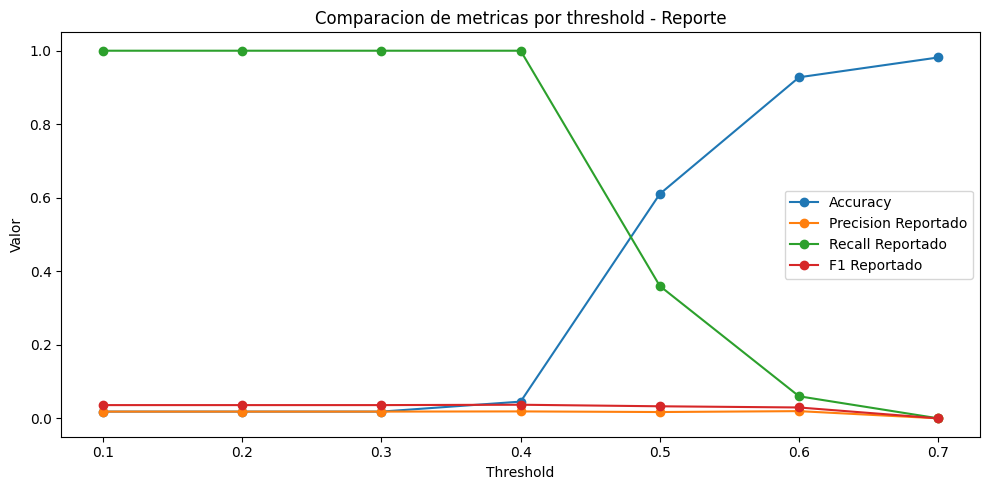

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(df_thresholds["threshold"], df_thresholds["accuracy"], marker="o", label="Accuracy")
plt.plot(df_thresholds["threshold"], df_thresholds["precision_reported"], marker="o", label="Precision Reportado")
plt.plot(df_thresholds["threshold"], df_thresholds["recall_reported"], marker="o", label="Recall Reportado")
plt.plot(df_thresholds["threshold"], df_thresholds["f1_reported"], marker="o", label="F1 Reportado")
plt.title("Comparacion de metricas por threshold - Reporte")
plt.xlabel("Threshold")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

## Grafica 8. Distribucion del riesgo derivado por plantilla

Esta figura resume la cantidad de plantillas clasificadas en riesgo bajo, medio y alto segun la puntuacion derivada definida en el cuaderno.


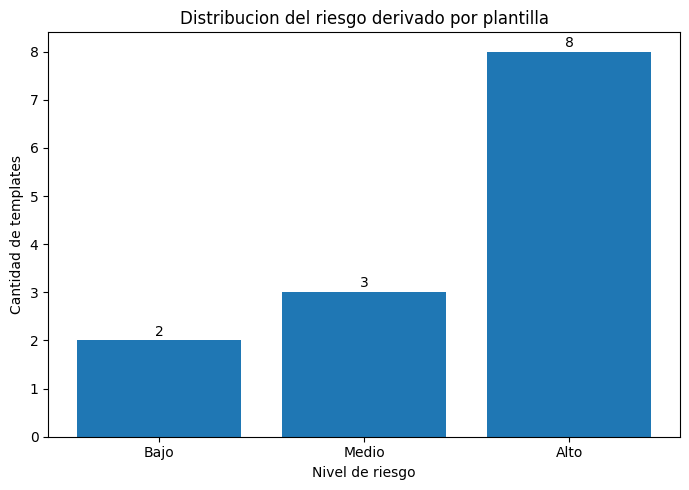

In [21]:
risk_dist = (
    df_risk_rules["risk_label_rule"]
    .value_counts()
    .reindex(["Bajo", "Medio", "Alto"], fill_value=0)
)

plt.figure(figsize=(7, 5))
plt.bar(risk_dist.index, risk_dist.values)
plt.title("Distribucion del riesgo derivado por plantilla")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de templates")
for i, v in enumerate(risk_dist.values):
    plt.text(i, v + 0.1, str(int(v)), ha="center")
plt.tight_layout()
plt.show()

## Grafica 9. Tasa de reporte observada por plantilla

La ultima visualizacion permite contrastar la frecuencia empirica de reporte por `template_id`, lo que ayuda a contextualizar la dificultad del problema conductual.


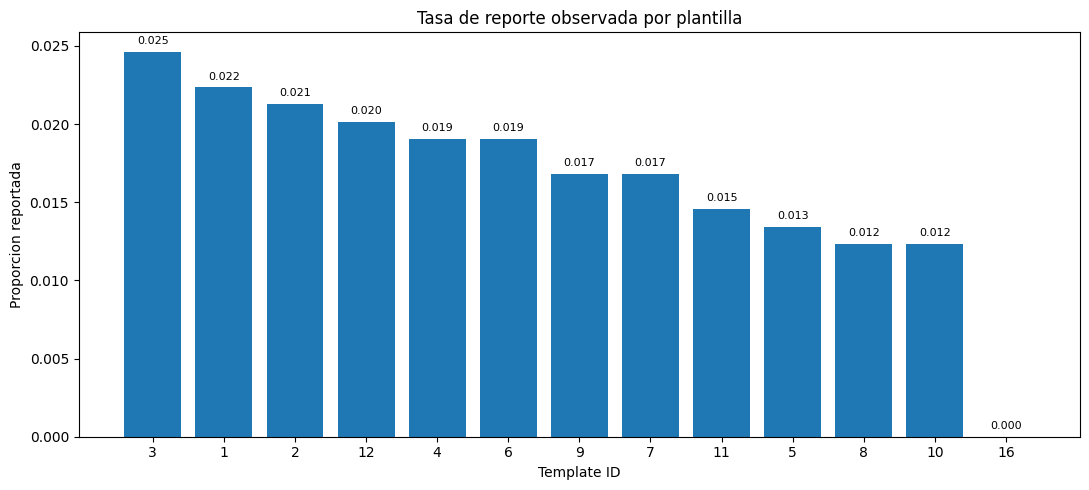

In [22]:
df_report_by_template = (
    df_report_result.groupby(["template_id", "template_subject"], as_index=False)["reported_target"]
    .mean()
    .rename(columns={"reported_target": "reported_rate"})
    .sort_values("reported_rate", ascending=False)
)

plt.figure(figsize=(11, 5))
plt.bar(df_report_by_template["template_id"].astype(str), df_report_by_template["reported_rate"])
plt.title("Tasa de reporte observada por plantilla")
plt.xlabel("Template ID")
plt.ylabel("Proporcion reportada")
for i, v in enumerate(df_report_by_template["reported_rate"]):
    plt.text(i, v + 0.0005, f"{v:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

# Graficas conceptuales de los algoritmos utilizados

Las siguientes figuras no corresponden a resultados empíricos del dataset, sino a una representacion didactica de los algoritmos principales utilizados durante el ejercicio:
- regresion lineal,
- regresion logistica,
- Random Forest.


## Grafica 10. Representacion conceptual de la regresion lineal

Se incluye como apoyo teorico para ilustrar el ajuste de una recta sobre datos continuos y diferenciarlo de los clasificadores usados en el proyecto.


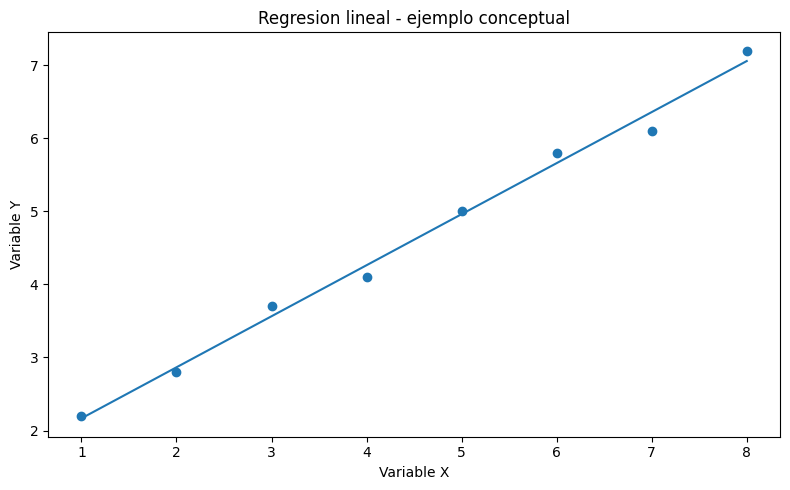

In [23]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([2.2, 2.8, 3.7, 4.1, 5.0, 5.8, 6.1, 7.2], dtype=float)

coef = np.polyfit(x, y, 1)
y_line = coef[0] * x + coef[1]

plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.plot(x, y_line)
plt.title("Regresion lineal - ejemplo conceptual")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.tight_layout()
plt.show()

## Grafica 11. Funcion sigmoide de la regresion logistica

Esta curva representa la transformacion probabilistica central de la regresion logistica, utilizada para clasificacion binaria y multietiqueta en este proyecto.


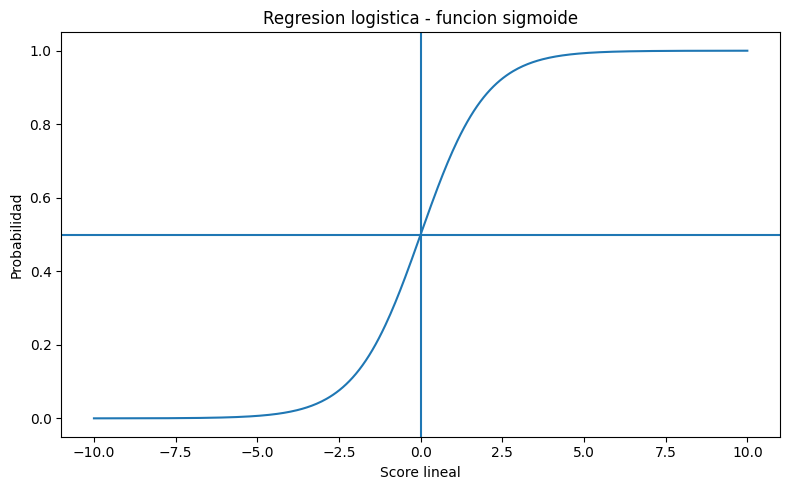

In [24]:
z = np.linspace(-10, 10, 400)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid)
plt.axhline(0.5)
plt.axvline(0)
plt.title("Regresion logistica - funcion sigmoide")
plt.xlabel("Score lineal")
plt.ylabel("Probabilidad")
plt.tight_layout()
plt.show()

## Grafica 12. Votacion conceptual en Random Forest

La figura ilustra el principio de agregacion de decisiones de multiples arboles, fundamento del modelo tabular empleado para la tarea de reporte.


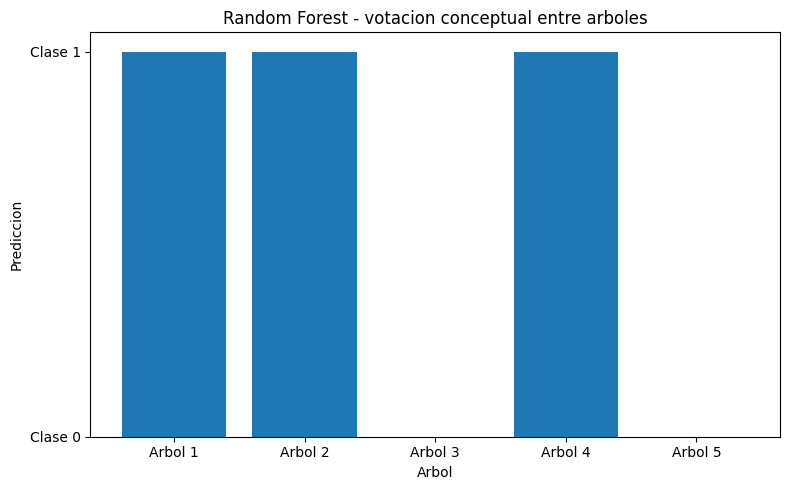

In [25]:
trees = ["Arbol 1", "Arbol 2", "Arbol 3", "Arbol 4", "Arbol 5"]
votes = [1, 1, 0, 1, 0]

plt.figure(figsize=(8, 5))
plt.bar(trees, votes)
plt.title("Random Forest - votacion conceptual entre arboles")
plt.xlabel("Arbol")
plt.ylabel("Prediccion")
plt.yticks([0, 1], ["Clase 0", "Clase 1"])
plt.tight_layout()
plt.show()

## Grafica 13. Importancia de variables del Random Forest

Esta visualizacion muestra las variables estructuradas con mayor peso relativo en el modelo final de reporte basado en bosques aleatorios.


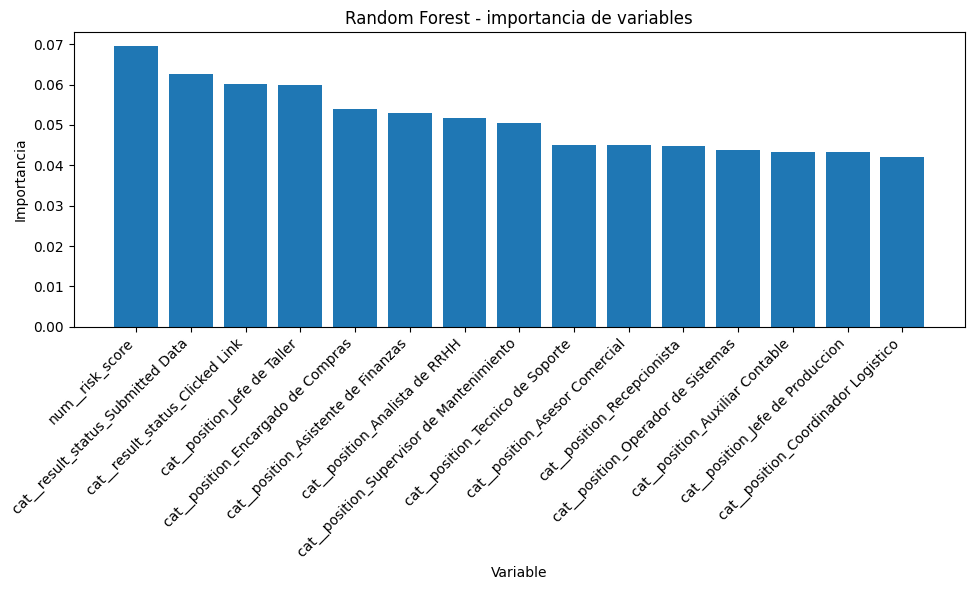

In [26]:
prep_rf = model_report_rf.named_steps["prep"]
clf_rf = model_report_rf.named_steps["clf"]

feature_names_rf = prep_rf.get_feature_names_out()
importances_rf = clf_rf.feature_importances_

df_rf_imp = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances_rf
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.bar(df_rf_imp["feature"], df_rf_imp["importance"])
plt.title("Random Forest - importancia de variables")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()